In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)   # Display all columns in backend and they cannot be show data in the frontend
pd.set_option('display.max_rows', None)      # Display all rows 

In [5]:
# apni file ka path daalen
df = pd.read_parquet('yellow_tripdata_2023-12.parquet')  
# agar CSV hai to: df = pd.read_csv('file.csv')

print(df.shape)   # kitni rows, kitne columns hain
df.head()          # pehli 5 rows dekhen
df.info()          # data types aur missing values ka andaza

(3376567, 19)
<class 'pandas.DataFrame'>
RangeIndex: 3376567 entries, 0 to 3376566
Data columns (total 19 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int32         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     str           
 7   PULocationID           int32         
 8   DOLocationID           int32         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airport_fee        

In [6]:
df.info()
df.dtypes

<class 'pandas.DataFrame'>
RangeIndex: 3376567 entries, 0 to 3376566
Data columns (total 19 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int32         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     str           
 7   PULocationID           int32         
 8   DOLocationID           int32         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airport_fee            float64   

VendorID                          int32
tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                 float64
trip_distance                   float64
RatecodeID                      float64
store_and_fwd_flag                  str
PULocationID                      int32
DOLocationID                      int32
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
Airport_fee                     float64
dtype: object

In [7]:
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100
missing_df = pd.DataFrame({'missing_count': missing, 'missing_percent': missing_percent})
print(missing_df[missing_df['missing_count'] > 0])

                      missing_count  missing_percent
passenger_count              180003         5.330947
RatecodeID                   180003         5.330947
store_and_fwd_flag           180003         5.330947
congestion_surcharge         180003         5.330947
Airport_fee                  180003         5.330947


In [8]:
print("Total duplicate rows:", df.duplicated().sum())

Total duplicate rows: 0


In [9]:
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])

In [10]:
df['trip_duration_minutes'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds() / 60
df['trip_duration_minutes'].describe()

count    3.376567e+06
mean     1.815948e+01
std      3.878404e+01
min     -5.995000e+01
25%      7.850000e+00
50%      1.328333e+01
75%      2.203333e+01
max      7.188317e+03
Name: trip_duration_minutes, dtype: float64

In [11]:
print("Negative duration:", (df['trip_duration_minutes'] < 0).sum())
print("Zero duration:", (df['trip_duration_minutes'] == 0).sum())
print("Less than 1 minute:", (df['trip_duration_minutes'] < 1).sum())
print("More than 3 hours (180 min):", (df['trip_duration_minutes'] > 180).sum())

# Passenger count check
print(df['passenger_count'].value_counts(dropna=False))

# Trip distance check
print("Zero distance trips:", (df['trip_distance'] == 0).sum())
print("Negative distance:", (df['trip_distance'] < 0).sum())

# Fare amount check (sirf audit ke liye, model mein use nahi karna kyunke leakage hai)
print("Negative fare:", (df['fare_amount'] < 0).sum())

Negative duration: 67
Zero duration: 1008
Less than 1 minute: 40684
More than 3 hours (180 min): 2715
passenger_count
1.0    2346555
2.0     513262
NaN     180003
3.0     137098
4.0      93498
0.0      42450
5.0      39430
6.0      24196
8.0         53
7.0         17
9.0          5
Name: count, dtype: int64
Zero distance trips: 73333
Negative distance: 0
Negative fare: 42642


In [ ]:
print("Unique pickup zones:", df['pickup_latitude'].nunique())
print("Unique dropoff zones:", df['dropoff_latitude'].nunique())

In [13]:
# Filtering thresholds (aap explain karenge report mein ke ye kyun chune)
df_clean = df[
    (df['trip_duration_minutes'] >= 1) &        # 1 min se kam trip = ghalat
    (df['trip_duration_minutes'] <= 180) &       # 3 ghante se zyada = outlier
    (df['trip_distance'] > 0) &                  # 0 distance = invalid
    (df['passenger_count'] > 0)                  # 0 passenger = invalid
]

print("Original rows:", len(df))
print("Clean rows:", len(df_clean))
print("Removed:", len(df) - len(df_clean))

Original rows: 3376567
Clean rows: 3097983
Removed: 278584


In [14]:
df_clean = df_clean.copy()  # warning avoid karne ke liye

df_clean['pickup_hour'] = df_clean['tpep_pickup_datetime'].dt.hour
df_clean['pickup_day'] = df_clean['tpep_pickup_datetime'].dt.day_name()
df_clean['pickup_month'] = df_clean['tpep_pickup_datetime'].dt.month

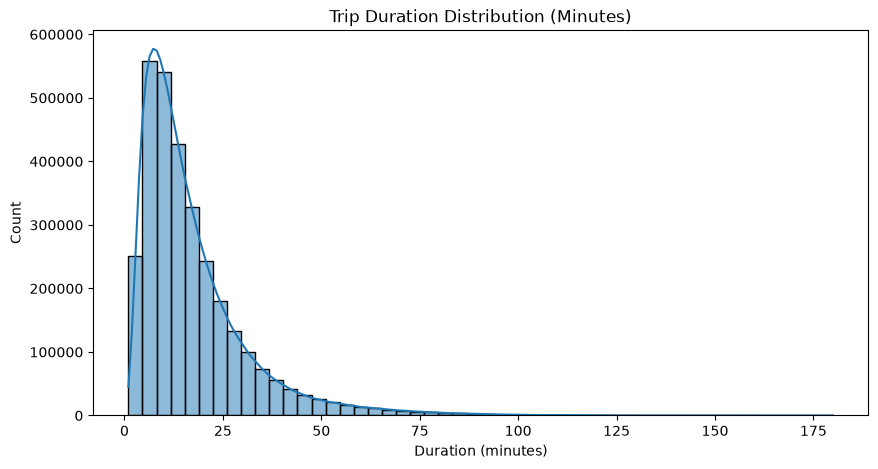

In [16]:
plt.figure(figsize=(10,5))
sns.histplot(df_clean['trip_duration_minutes'], bins=50, kde=True)
plt.title('Trip Duration Distribution (Minutes)')
plt.xlabel('Duration (minutes)')
plt.show()

# Ye aapko dikhayega ke zyada tar trips kitni der ki hoti hain (shayad right-skewed hoga, matlab zyada trips short honge, kuch bohot lambi).

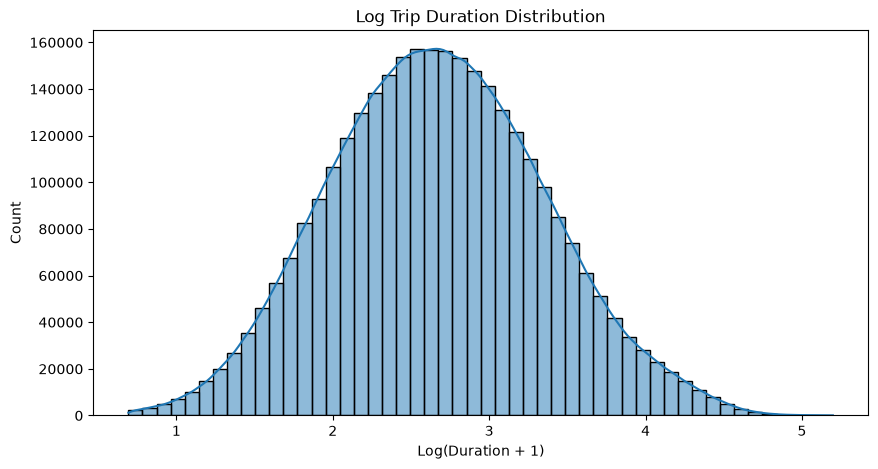

In [17]:
df_clean['log_duration'] = np.log1p(df_clean['trip_duration_minutes'])

plt.figure(figsize=(10,5))
sns.histplot(df_clean['log_duration'], bins=50, kde=True)
plt.title('Log Trip Duration Distribution')
plt.xlabel('Log(Duration + 1)')
plt.show()

# yeh aapko dikhayega ke log transformation ke baad distribution zyada normal (bell-shaped) ho jata hai, jo regression models ke liye better hota hai.

# Farq dekhen dono graphs mein — pehla wala lamba tail wala hoga (skewed), doosra zyada bell-shape (normal) jaisa hoga.

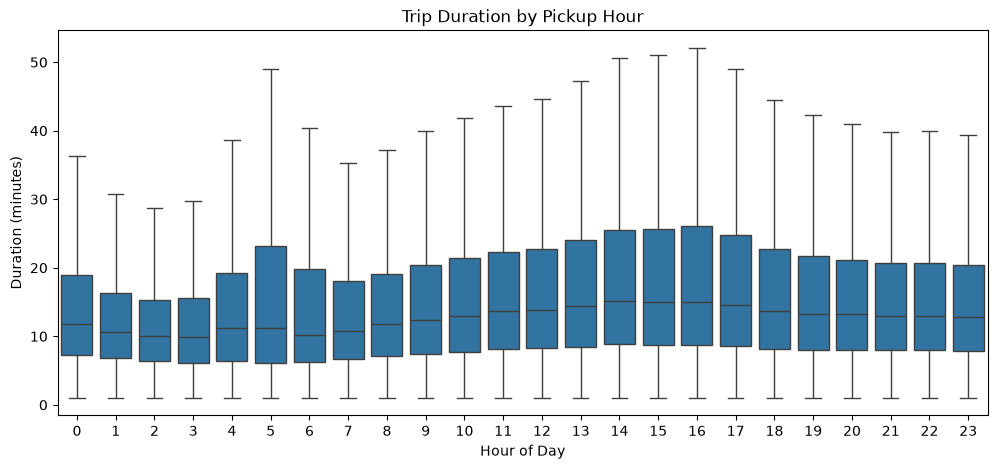

In [18]:
plt.figure(figsize=(12,5))
sns.boxplot(x='pickup_hour', y='trip_duration_minutes', data=df_clean, showfliers=False)
plt.title('Trip Duration by Pickup Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Duration (minutes)')
plt.show()


# Ye aapko dikhayega ke din ke kis time par trips zyada lambi ya choti hoti hain.
# showfliers=False isliye lagaya taake outliers graph ko squeeze na karen — sirf normal range dikhega.

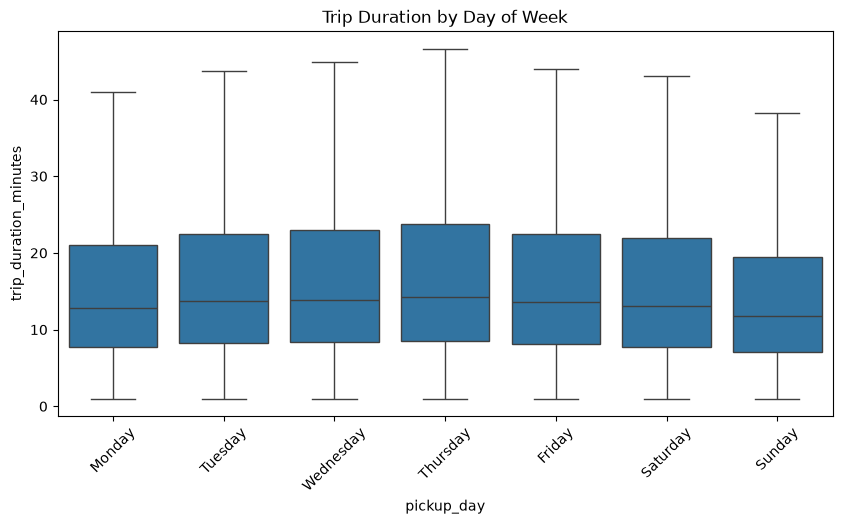

In [19]:
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

plt.figure(figsize=(10,5))
sns.boxplot(x='pickup_day', y='trip_duration_minutes', data=df_clean, order=order, showfliers=False)
plt.title('Trip Duration by Day of Week')
plt.xticks(rotation=45)
plt.show()

# Ye aapko dikhayega ke hafte ke kis din trips zyada lambi ya choti hoti hain.

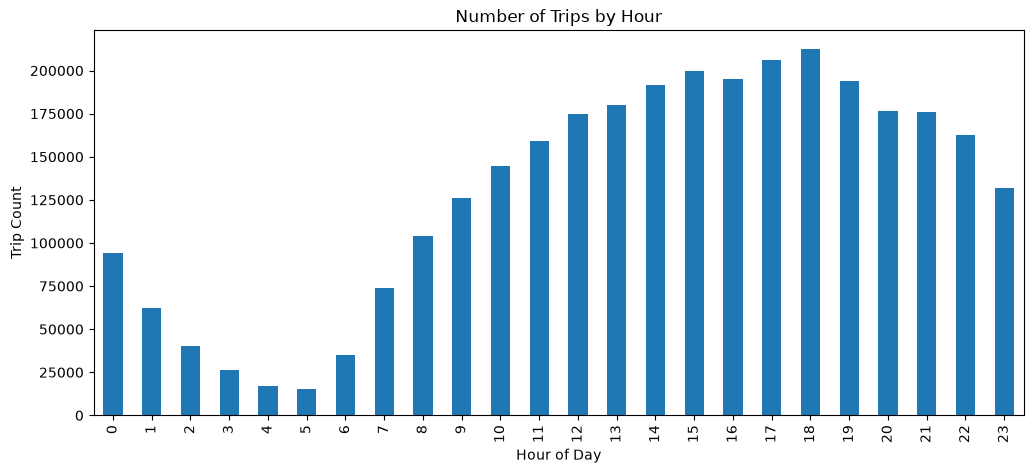

In [20]:
plt.figure(figsize=(12,5))
df_clean['pickup_hour'].value_counts().sort_index().plot(kind='bar')
plt.title('Number of Trips by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Trip Count')
plt.show()

# Ye aapko dikhayega ke din ke kis time par zyada trips hoti hain.

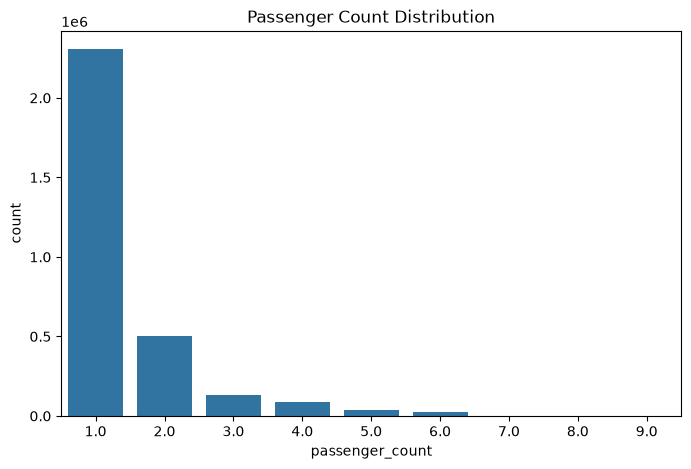

In [21]:
plt.figure(figsize=(8,5))
sns.countplot(x='passenger_count', data=df_clean)
plt.title('Passenger Count Distribution')
plt.show()

# Ye aapko dikhayega ke zyada tar trips mein kitne passengers hote hain.

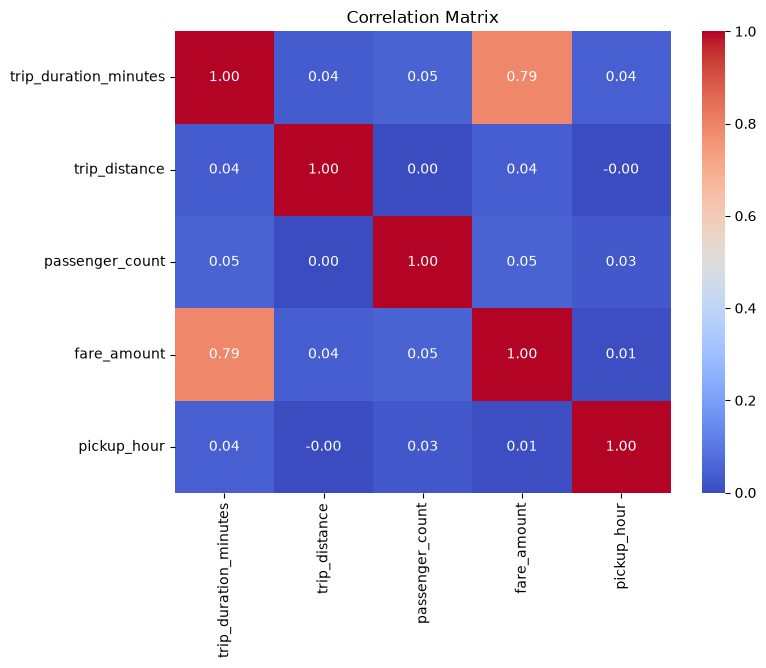

In [22]:
numeric_cols = ['trip_duration_minutes', 'trip_distance', 'passenger_count', 'fare_amount', 'pickup_hour']

plt.figure(figsize=(8,6))
sns.heatmap(df_clean[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

# Ye aapko dikhayega ke kaunse numeric features ek doosre se kitne correlated hain. High correlation wale features ko model mein carefully use karna chahiye, kyunki multicollinearity ka issue ho sakta hai.